<a href="https://colab.research.google.com/github/xxmadara1xx/Controllo-LED-tramite-UART/blob/main/test_yolov8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚁 اختبار YOLOv8 على صور وفيديوهات
### شغّل الخلايا بالترتيب

In [ ]:
# الخلية 1: تثبيت
!pip install ultralytics -q
print('✅ تم التثبيت!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.5 MB/s eta 0:00:00
✅ تم التثبيت!


In [ ]:
# الخلية 2: ربط Drive
from google.colab import drive
drive.mount('/content/drive')
print('\n📂 ملفاتك في Drive:')
!ls /content/drive/MyDrive/

Mounted at /content/drive

📂 ملفاتك في Drive:
 best_sky.pt	    result_video.mp4   test2.jpeg   v12.mp4   v3.mp4
 best_sky_v2.pt     t1.jpg	       test3.jpeg   v15.mp4   v5.mp4
 best_unified.pt    t2.jpg	       test4.jpg    v16.mp4   v7.mp4
'Colab Notebooks'   t3.jpeg	       test6.jpeg   v17.mp4   v8.mp4
 i1.jpg		    t4.jpeg	       v10.mp4	    v1.mp4    v9.mp4
 result_image.jpg   test1.jpeg	       v11.mp4	    v2.mp4


In [ ]:
# الخلية 3: تحميل النموذج
from ultralytics import YOLO

# يمكنك استخدام best_sky.pt أو yolov8x.pt
# إذا عندك best_sky.pt في Drive:
# model = YOLO('/content/drive/MyDrive/best_sky.pt')

# أو النموذج الجاهز:
model = YOLO('yolov8x.pt')
print('✅ تم تحميل النموذج!')
print(f'📋 الفئات: {model.names}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ تم تحميل النموذج!
📋 الفئات: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon'

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128641 (\N{HELICOPTER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


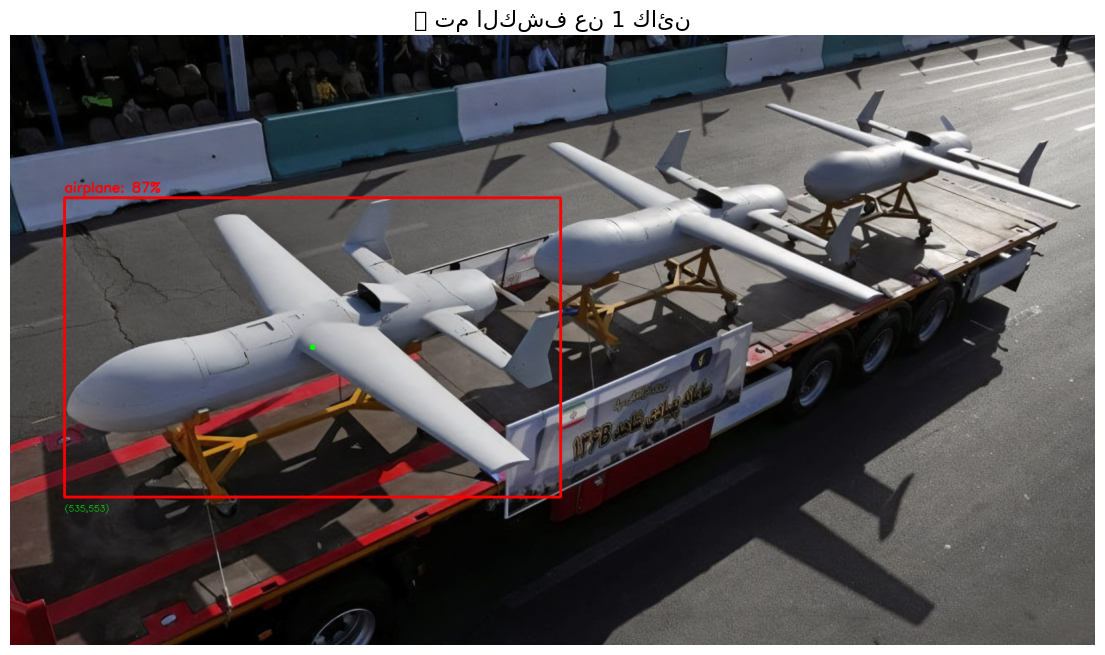

✅ عدد الكائنات: 1
💾 محفوظة: result_image.jpg


In [ ]:

# الخلية 4: كشف على صورة
import cv2
import matplotlib.pyplot as plt
import os

# ✏️ غير اسم الصورة
IMAGE_NAME = 'i1.jpg'
IMAGE_PATH = f'/content/drive/MyDrive/{IMAGE_NAME}'
CONF       = 0.25
ALLOWED    = ['airplane', 'helicopter', 'bird', 'kite']

if not os.path.exists(IMAGE_PATH):
    print(f'❌ الصورة غير موجودة: {IMAGE_NAME}')
else:
    results = model(IMAGE_PATH, conf=CONF, verbose=False)
    frame   = cv2.imread(IMAGE_PATH)
    count   = 0
    h, w    = frame.shape[:2]

    for box in results[0].boxes:
        cls_id     = int(box.cls[0])
        class_name = model.names[cls_id]
        conf_val   = float(box.conf[0])

        # فلتر الفئات
        if class_name not in ALLOWED:
            continue

        x1,y1,x2,y2 = map(int, box.xyxy[0])

        # تجاهل المربعات الكبيرة
        if (x2-x1)*(y2-y1) > h*w*0.8:
            continue

        count += 1
        cx,cy  = (x1+x2)//2, (y1+y2)//2

        cv2.rectangle(frame, (x1,y1), (x2,y2), (0,0,255), 3)
        label = f'{class_name}: {conf_val*100:.0f}%'
        cv2.putText(frame, label, (x1, max(y1-10,20)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,255), 2)
        cv2.circle(frame, (cx,cy), 5, (0,255,0), -1)
        cv2.putText(frame, f'({cx},{cy})', (x1, y2+25),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

    # حفظ وعرض
    cv2.imwrite('/content/drive/MyDrive/result_image.jpg', frame)

    plt.figure(figsize=(14,8))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title(f'🚁 تم الكشف عن {count} كائن', fontsize=16)
    plt.axis('off')
    plt.show()
    print(f'✅ عدد الكائنات: {count}')
    print(f'💾 محفوظة: result_image.jpg')

In [ ]:
# الخلية 5: كشف على فيديو
import shutil
from IPython.display import HTML, display
from base64 import b64encode

# ✏️ غير اسم الفيديو
VIDEO_NAME = 'v17.mp4'
VIDEO_PATH = f'/content/drive/MyDrive/{VIDEO_NAME}'
CONF       = 0.25
MAX_FRAMES = 9999

if not os.path.exists(VIDEO_PATH):
    print(f'❌ الفيديو غير موجود: {VIDEO_NAME}')
else:
    shutil.copy(VIDEO_PATH, '/content/input.mp4')

    cap    = cv2.VideoCapture('/content/input.mp4')
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = max(int(cap.get(cv2.CAP_PROP_FPS)), 25)
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f'📹 {width}x{height} @ {fps}fps | {total} إطار')

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out    = cv2.VideoWriter('/content/output_raw.mp4', fourcc, fps, (width, height))

    frame_count  = 0
    drone_frames = 0

    while cap.isOpened() and frame_count < MAX_FRAMES:
        ret, frame = cap.read()
        if not ret:
            break

        results = model(frame, conf=CONF, verbose=False)
        count   = 0

        for box in results[0].boxes:
            cls_id     = int(box.cls[0])
            class_name = model.names[cls_id]
            conf_val   = float(box.conf[0])
            x1,y1,x2,y2 = map(int, box.xyxy[0])
            count += 1
            cv2.rectangle(frame, (x1,y1), (x2,y2), (0,0,255), 3)
            label = f'{class_name}: {conf_val*100:.0f}%'
            cv2.putText(frame, label, (x1, max(y1-10,20)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,255), 2)

        if count > 0:
            drone_frames += 1
            cv2.putText(frame, f'DETECTED! ({count})', (20,50),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0,0,255), 3)

        cv2.putText(frame, f'Frame:{frame_count}/{min(MAX_FRAMES,total)}',
                    (20, height-20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

        out.write(frame)
        frame_count += 1
        if frame_count % 30 == 0:
            print(f'  ⏳ {frame_count}/{min(MAX_FRAMES,total)} إطار...')

    cap.release()
    out.release()

    !ffmpeg -i /content/output_raw.mp4 -vcodec libx264 /content/final.mp4 -y -loglevel quiet
    shutil.copy('/content/final.mp4', '/content/drive/MyDrive/result_video.mp4')

    print(f'\n✅ اكتمل! {drone_frames}/{frame_count} إطار')
    print(f'💾 محفوظ: result_video.mp4')

    mp4      = open('/content/final.mp4','rb').read()
    data_url = 'data:video/mp4;base64,' + b64encode(mp4).decode()
    display(HTML(f'<video width=640 controls><source src="{data_url}" type="video/mp4"></video>'))

📹 768x432 @ 30fps | 300 إطار
  ⏳ 30/300 إطار...
  ⏳ 60/300 إطار...
  ⏳ 90/300 إطار...
  ⏳ 120/300 إطار...
  ⏳ 150/300 إطار...
  ⏳ 180/300 إطار...
  ⏳ 210/300 إطار...
  ⏳ 240/300 إطار...
  ⏳ 270/300 إطار...
